# analysis.cooccurrence-habitat

In this notebook, we aim to understand:
- how cooccurrences are distributed across sites
- how cooccurrences could be related with site species richness

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from daforfer import DaforferDB
import matplotlib.pyplot as plt
import networkx as nx
plt.rcParams['svg.fonttype'] = 'none'
from yaml import load, Loader
from daforfer import DaforferDB
conf = load(open("conf.yaml"), Loader)
db = DaforferDB(conf['database'])
db.toc()

/home/bcz/miniconda3/envs/miripvir25/lib/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


┌──────────────────────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│                 name                 │                                                                                  description                                                                                   │
│               varchar                │                                                                                    varchar                                                                                     │
├──────────────────────────────────────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ D_bacteriaHits                       │ This table contains all the MOTUS hits obtained, regardless of their status. It contain

## Load data

We will compute the cooccurrences from the network directly.

*TODO*: Use the right table instead.

In [2]:
cooccurrence_network = nx.read_graphml("output/network.coocurrence.virusbact-bylibrary.trans.graphml")
cooccurrence_network.number_of_edges()

57

We need to use original hit tables, as we will use the OTUs scientific names to make subgraphs on the cooccurrence network.

In [3]:

# metadata = pd.read_csv("output/metadata.site-library.csv", sep=";")
# bacteria_hits = pd.read_csv("output/hits.bacteria.csv", sep=";").query("is_pab==True")
metadata = db.conn.sql("SELECT * FROM D_sites").df()
bacteria_hits = db.conn.sql("SELECT * FROM D_PABHits").df()
bacteria_hits = pd.merge(metadata, bacteria_hits, on='library', how='left').dropna(subset='taxid')
bacteria_hits['taxid'] = bacteria_hits['taxid'].astype(int)

# virus_hits = pd.read_csv("output/hits.virus.csv", sep=";")
virus_hits = db.conn.sql("SELECT * FROM D_virusHits").df()
virus_hits = pd.merge(metadata, virus_hits, on='library', how='left').dropna(subset='taxid')
virus_hits['taxid'] = virus_hits['taxid'].astype(int)


hits = pd.concat([
    bacteria_hits[['site', 'habitat', 'scientific_name']],
    virus_hits[['site', 'habitat', 'scientific_name']],
]).drop_duplicates(['site', 'habitat', 'scientific_name'], keep='first')

## Compute number of cooccurrences by site

We look for subgraphs of the cooccurrence graph within each of the sites

In [4]:
site_cooccurrences = []
for site in hits.site.unique():
    site_cooccurrence_subnetwork = cooccurrence_network.subgraph(
        hits.query('site == "{:s}"'.format(site))['scientific_name'].to_list()
    )
    site_cooccurrences.append({
        "site": site,
        "total_cooccurrences": site_cooccurrence_subnetwork.number_of_edges()
    })
site_cooccurrences = pd.DataFrame.from_records(site_cooccurrences)
site_cooccurrences
    

,site,total_cooccurrences
0,C1,5
1,C2,6
2,E1,8
3,E2,5
4,E3,11
5,E4,21
6,H1,0
7,H2,2
8,H3,5
9,L1,34


In [5]:
site_cooccurrences = pd.merge(
    site_cooccurrences, # type: ignore
    hits.drop_duplicates(['site', 'habitat'], keep='first')[['site', 'habitat']]
)
db.save_dataframe(
    site_cooccurrences, table_name="D_coocBySite",
    description="Number of cooccurring pairs detected at the each site"
)
site_cooccurrences

Saved D_coocBySite to 2025-10-21


,site,total_cooccurrences,habitat
0,C1,5,Crop
1,C2,6,Crop
2,E1,8,Wasteland
3,E2,5,Wasteland
4,E3,11,Wasteland
5,E4,21,Wasteland
6,H1,0,Crop
7,H2,2,Crop
8,H3,5,Crop
9,L1,34,Edge


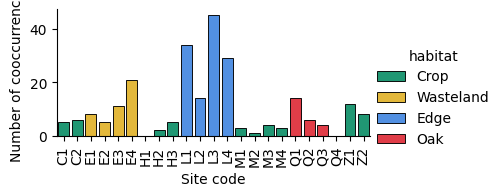

In [6]:
g = sns.catplot(site_cooccurrences, x='site', y='total_cooccurrences', height=2.0, aspect=2.0, kind='bar', hue='habitat', palette=conf['habitat_palette'], edgecolor='black', linewidth=0.65)
# g.axes[0, 0].set_yscale('log')
g.set_ylabels("Number of cooccurrences")
g.set_xlabels("Site code")
g.set_xticklabels(rotation=90)
g.savefig("figures/barplot.species-richness.colbyhabitat.svg")

In [7]:
site_cooccurrences['disturbed'] = site_cooccurrences['habitat'].apply(
    lambda x: {'Crop': True, 'Edge': True, 'Oak': False, 'Wasteland': False}[x]
).astype(str)

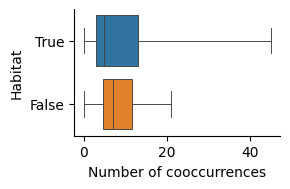

In [8]:
g = sns.catplot(site_cooccurrences, y='disturbed', x='total_cooccurrences', height=2.0, aspect=1.5, hue='disturbed', linewidth=0.65, kind='box', whis=1000)
# g.axes[0, 0].set_yscale('log')
g.set_xlabels("Number of cooccurrences")
g.set_ylabels("Habitat")
# g.set_xticklabels(rotation=90)
# g.savefig("figures/barplot.species-richness.colbyhabitat.svg")

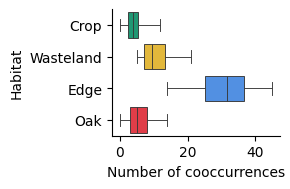

In [9]:
g = sns.catplot(site_cooccurrences, y='habitat', x='total_cooccurrences', height=2.0, aspect=1.5, hue='habitat', palette=conf['habitat_palette'], linewidth=0.65, kind='box', whis=1000)
# g.axes[0, 0].set_yscale('log')
g.set_xlabels("Number of cooccurrences")
g.set_ylabels("Habitat")
# g.set_xticklabels(rotation=90)
# g.savefig("figures/barplot.species-richness.colbyhabitat.svg")

In [10]:
stats.kruskal(
    site_cooccurrences.query('habitat == "Crop"')['total_cooccurrences'],
    site_cooccurrences.query('habitat == "Edge"')['total_cooccurrences'],
    site_cooccurrences.query('habitat == "Oak"')['total_cooccurrences'],
    site_cooccurrences.query('habitat == "Wasteland"')['total_cooccurrences'],
)

KruskalResult(statistic=11.818023833167826, pvalue=0.008033255691626467)

In [11]:
stats.mannwhitneyu(
    site_cooccurrences.query('habitat == "Crop" or habitat == "Edge"')['total_cooccurrences'],
    site_cooccurrences.query('habitat == "Oak" or habitat == "Wasteland"')['total_cooccurrences']
)

MannwhitneyuResult(statistic=55.5, pvalue=0.7957593834324872)

### Post-hoc analysis

In [12]:
post_hoc_stats = []

for h1 in ['Crop', 'Edge', 'Wasteland', 'Oak']:
    for h2 in ['Crop', 'Edge', 'Wasteland', 'Oak']:
        if h1 != h2:
            kw_h, pval = stats.mannwhitneyu(
                site_cooccurrences.query('habitat == "{0}"'.format(h1))['total_cooccurrences'].values,
                site_cooccurrences.query('habitat == "{0}"'.format(h2))['total_cooccurrences'].values,
            )
            significative = pval < 0.05
            post_hoc_stats.append(
                {'group_1': h1, 'group_2': h2, 'H': kw_h, 'p-val': pval, 'sign': significative}
            )
post_hoc_stats = pd.DataFrame.from_records(post_hoc_stats)

db.save_dataframe(
    df=post_hoc_stats, table_name="T_coocByHabitat",
    description="Post-Hoc Mann Whitney U analysis on number of cooccurrennt pairs by habitat"
)

post_hoc_stats

Saved T_coocByHabitat to 2025-10-21


,group_1,group_2,H,p-val,sign
0,Crop,Edge,0.0,0.004923,True
1,Crop,Wasteland,6.5,0.048959,True
2,Crop,Oak,18.5,0.693998,False
3,Edge,Crop,44.0,0.004923,True
4,Edge,Wasteland,15.0,0.057143,False
5,Edge,Oak,15.5,0.042066,True
6,Wasteland,Crop,37.5,0.048959,True
7,Wasteland,Edge,1.0,0.057143,False
8,Wasteland,Oak,12.0,0.342857,False
9,Oak,Crop,25.5,0.693998,False


## Correlation between site-alpha-diversity and site-number of cooccurrences

In [13]:
# alpha_diversity = pd.read_csv("output/diversity.all.csv", sep=";")
alpha_diversity = db.conn.sql('SELECT * FROM D_ADAllOrganismsSite').df().drop(columns=['disturbed'])
alpha_diversity = pd.merge(alpha_diversity, site_cooccurrences, on=['site', 'habitat'])
db.save_dataframe(
    alpha_diversity, table_name="Alpha_diversity_bysite_cooccurrences",
    description="Alpha diveristy and cooccurrences by site"
)
alpha_diversity

Saved Alpha_diversity_bysite_cooccurrences to 2025-10-21


,site,habitat,species_richness_bact,species_richness_vir,species_richness_plant,species_richness_host,total_cooccurrences,disturbed
0,C1,Crop,6,18,16,4,5,True
1,C2,Crop,8,12,22,5,6,True
2,H1,Crop,1,12,6,3,0,True
3,H2,Crop,1,12,5,3,2,True
4,H3,Crop,4,33,9,4,5,True
5,M1,Crop,2,19,14,5,3,True
6,M2,Crop,1,12,9,4,1,True
7,M3,Crop,2,9,11,4,4,True
8,M4,Crop,1,8,15,3,3,True
9,Z1,Crop,11,12,13,6,12,True


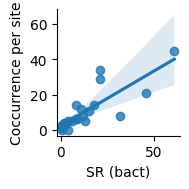

In [14]:
g = sns.lmplot(alpha_diversity, x='species_richness_bact', y='total_cooccurrences', height=2.0)
g.set_xlabels("SR (bact)")
g.set_ylabels("Coccurrence per site")

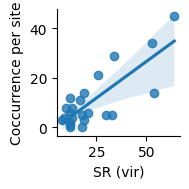

In [15]:
g = sns.lmplot(alpha_diversity, x='species_richness_vir', y='total_cooccurrences', height=2.0)
g.set_xlabels("SR (vir)")
g.set_ylabels("Coccurrence per site")

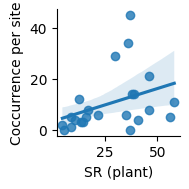

In [16]:
g = sns.lmplot(alpha_diversity, x='species_richness_plant', y='total_cooccurrences', height=2.0)
g.set_xlabels("SR (plant)")
g.set_ylabels("Coccurrence per site")

In [17]:
def reg2dict(x, level):

    return {"level": level, "p-value": x.pvalue, "r-value": x.rvalue, "slope": x.slope}
regression_tests = pd.DataFrame.from_records([
    reg2dict(stats.linregress(alpha_diversity['species_richness_bact'], alpha_diversity['total_cooccurrences']), "Bact"),
    reg2dict(stats.linregress(alpha_diversity['species_richness_vir'], alpha_diversity['total_cooccurrences']), "Virus"),
    reg2dict(stats.linregress(alpha_diversity['species_richness_plant'], alpha_diversity['total_cooccurrences']), "Plant")
])

db.save_dataframe(
    regression_tests, table_name='T_coocDivBySite',
    description='Correlation tests between species richness and number of coocurrences detected at each site'
)
regression_tests

Saved T_coocDivBySite to 2025-10-21


,level,p-value,r-value,slope
0,Bact,0.000002,0.815848,0.619368
1,Virus,0.000006,0.793030,0.589342
2,Plant,0.086325,0.365513,0.257978


In [18]:
db.conn.close()